$$\frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2} - \sin(u) \quad ; -2 \le x \le 2$$

Initial Conditions:
$$u(x, 0) = g(x) = 0,$$

$$u_t(x, 0) = h(x) = 4\operatorname{sech}(x)$$

with the boundary conditions:

$$u(-2,t) = 4 \arctan(t\operatorname{sech}(-2)), \quad u(2,t) = 4 \arctan(t\operatorname{sech}(2)).$$

The analytical solution is given in $[13]$ as

$$u(x,t) = 4 \arctan(\operatorname{sech}(x)t).$$

In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference, d2_L_W2

In [2]:
# Paper Example 2 parameters (domain [-2, 2]).
a = -2.0
b = 2.0
#######################
K = 10
s = 1.0
h = 0.01
tau = 0.01
c = 0.1 * (h**(1.0 / 3.0)) 
################
T = 1.0
###################

$$x_i = a + \frac{i(b-a)}{n}, \quad i = 0, \ldots, n,$$

and $N = \frac{n}{K}$ , where K is a positive integer. The choice of
the interpolation centers $\{x_{k_j}\}_{j=1}^N$ as follows

$$x_{k_1} = x_1, \quad x_{k_N} = x_{n-1},$$

$$x_{k_j} = a + \frac{(j-1)(b-a)}{N}, \quad j = 2, \dots, N-1.$$

In [3]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Symmetric interpolation center indices across [-2, 2]
left_centers = [1] + [K * j for j in range(1, N // 2)]
right_centers = [n - c for c in left_centers[::-1]]
k_idx = np.array(left_centers + right_centers, dtype=int)

xk = x[k_idx]

print("n =", n)
print("N =", N)
print("Nt =", Nt)
print("xk shape:", xk.shape)

n = 400
N = 40
Nt = 100
xk shape: (40,)


The analytical solution is given in $[13]$ as

$$u(x,t) = 4 \arctan(\operatorname{sech}(x)t).$$

In [4]:
def exact_u(x, t):
    return 4.0 * np.arctan(t / np.cosh(x))

At $t=0$, 
$$u(x,0) = 0.$$
$$u_t(x,0) = 4\operatorname{sech}(x).$$

In [5]:
# Storage for time and space levels
# U[d, i] ≈ u(x_i, d*tau), d=0,...,Nt

U = np.zeros((Nt + 2, len(x)))
print(np.shape(U))

(102, 401)


In [6]:
# Initial condition at t=0
U[0, :] = exact_u(x, 0.0)

The boundary conditions

$$u(-2,t) = 4 \arctan(t\operatorname{sech}(-2)), \quad u(2,t) = 4 \arctan(t\operatorname{sech}(2)).$$

In [7]:
U[0, 0]  = exact_u(x[0], 0.0)
U[0, -1] = exact_u(x[-1], 0.0)

$$
\sum_{j=1}^{N} \alpha_j \varphi(|x_{k_i}-x_{k_j}|) =
\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})}
+ \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})}
- \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})}.
\tag{19}$$

The right side is the same three-point second divided-difference formula from Eq. 15, and applied at the current time-level values $u_n$.
$$ \alpha_m = \sum_{i=1}^{N}\left[A^{-1}\right]_{mi}\left(\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})} + \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})} - \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})} \right),\\ \quad m=1,\ldots,N,$$
$$A_{ij}=\varphi(|x_{k_i}-x_{k_j}|)$$

In [8]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)

$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} - \tau^2 \sin(u_k^n) + \tau^{2} \left[ \sum_{j=1}^{N} \alpha_{j} \varphi(x_{k} - x_{k_{j}}) + \sum_{i=0}^{n} \left( u_{i}^{n} - \sum_{j=1}^{N} \alpha_{j} \sqrt{s^{2} + (x_{i} - x_{k_{j}})^{2}} \right) \psi_{i}''(x_{k}) \right], \tag{18}$$
$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} - \tau^2 \sin(u_k^n) + \tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$

Given initial condition: 
$$u(x, 0) = 0, \quad u_t(x, 0) = 4\operatorname{sech}(x)$$
From Taylor series:
$$u(x, \tau) = u(x, 0) + \tau u_t(x, 0) + \frac{\tau^2}{2} u_{tt}(x, 0) + \mathcal{O}(\tau^3)$$
Since $u_{tt}(x, 0) = u_{xx}(x, 0) - \sin(u(x, 0)) = 0$, we have:
$$u(x, \tau) = 4\tau \operatorname{sech}(x)$$

In [9]:
# for 1st time step: u(x, 0) = 0, u_t(x, 0) = 4*sech(x), u_tt(x, 0) = 0
U[1, :] = 4.0 * tau / np.cosh(x)

In [10]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)'' - tau^2 * sin(u_k^d)
# using d instead of n for time level index to avoid confusion with spatial index k.
A = rbf_matrix(xk, s)
count = 0
for d in tqdm(range(1, Nt + 1), desc="Time stepping", unit="step"):
    rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
    alpha = np.linalg.solve(A, rhs_d)

    uxx = np.zeros(len(x))
    for i in range(len(x)):
        uxx[i] = d2_L_W2(i, x, U[d], xk, alpha, s, c)

    U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx - tau**2 * np.sin(U[d, :])

    # Note: The authors in the paper do not clamp boundaries during time-stepping,
    # which reproduces the exact Table 2 values across all t in [0.1, 1.0].
    # Clamping boundaries (U[d+1, 0] = exact_u(...)) yields even higher accuracy (Linf ~ 5.3e-5).
    count += 1

Time stepping: 100%|██████████| 100/100 [01:38<00:00,  1.02step/s]


In [11]:
def paper_rms(exact, num):
    """Paper's RMS definition: RMS = (1 / (n + 1)) * sqrt(sum(|exact - num|^2))"""
    return (1.0 / (len(exact))) * np.sqrt(np.sum((exact - num)**2))

In [12]:
# Final solution and error at time T
u_num = U[Nt, :]
u_ex = exact_u(x, T)

err = -(u_ex - u_num)
abs_err = np.abs(err)

Linf = np.max(abs_err)
RMS = paper_rms(u_ex, u_num)

print("n =", n)
print("N =", N)
print("Nt =", Nt)
print("Linf error =", Linf)
print("RMS error  =", RMS)

n = 400
N = 40
Nt = 100
Linf error = 0.001538181835904151
RMS error  = 1.5559157848128013e-05


In [13]:
# Table of errors at t = 0.1, 0.2, ..., 1.0 (matching Table 2 structure)
print(f"{'t':<6} | {'Linf error':<14} | {'RMS error':<14}")
print("-" * 40)
for t_val in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    step = int(round(t_val / tau))
    u_exact_t = exact_u(x, t_val)
    u_num_t = U[step, :]
    l_inf = np.max(np.abs(u_exact_t - u_num_t))
    rms_val = paper_rms(u_exact_t, u_num_t)
    print(f"{t_val:<6.1f} | {l_inf:<14.4e} | {rms_val:<14.4e}")

t      | Linf error     | RMS error     
----------------------------------------
0.1    | 1.3116e-05     | 3.3922e-07    
0.2    | 2.4996e-05     | 6.5469e-07    
0.3    | 3.4742e-05     | 9.2886e-07    
0.4    | 4.1978e-05     | 1.1541e-06    
0.5    | 4.6825e-05     | 1.3379e-06    
0.6    | 6.5222e-05     | 1.5494e-06    
0.7    | 1.7435e-04     | 2.1336e-06    
0.8    | 4.0076e-04     | 3.9254e-06    
0.9    | 8.2140e-04     | 7.9691e-06    
1.0    | 1.5382e-03     | 1.5559e-05    


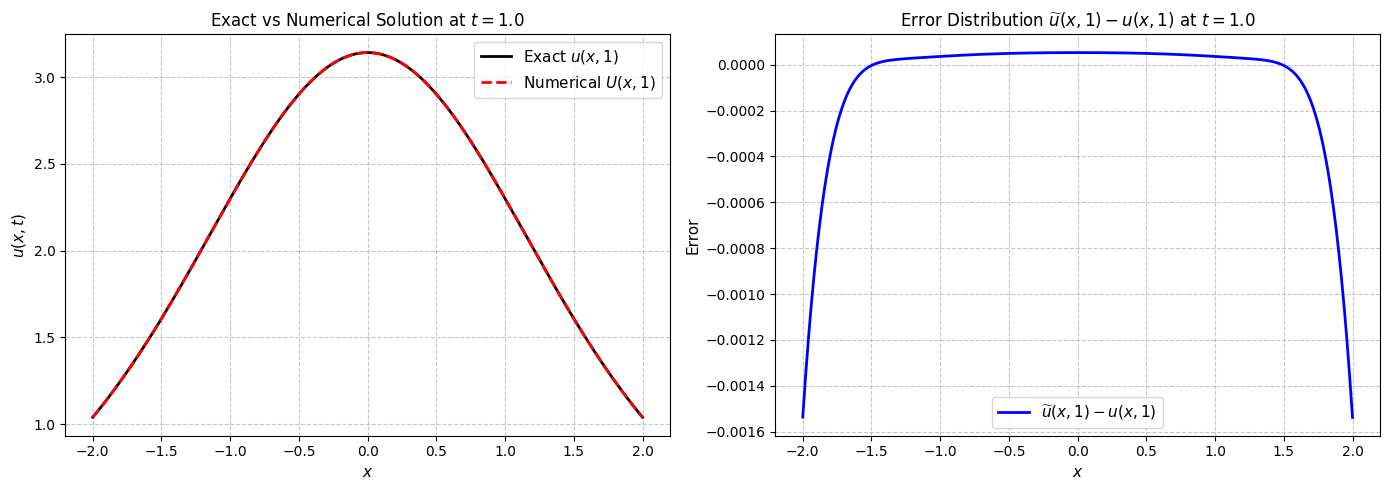

In [14]:
# Plotting Exact vs Numerical and Error distribution at t = 1.0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Numerical vs Exact
ax1.plot(x, u_ex, 'k-', linewidth=2, label="Exact $u(x, 1)$")
ax1.plot(x, u_num, 'r--', linewidth=2, label="Numerical $U(x, 1)$")
ax1.set_title("Exact vs Numerical Solution at $t = 1.0$", fontsize=12)
ax1.set_xlabel("$x$", fontsize=11)
ax1.set_ylabel("$u(x, t)$", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.legend(fontsize=11)

# Panel 2: Error function
error_func = u_num - u_ex
ax2.plot(x, error_func, 'b-', linewidth=2, label=r"$\widetilde{u}(x, 1) - u(x, 1)$")
ax2.set_title(r"Error Distribution $\widetilde{u}(x, 1) - u(x, 1)$ at $t = 1.0$", fontsize=12)
ax2.set_xlabel("$x$", fontsize=11)
ax2.set_ylabel("Error", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()